# Try DRIMC in Python

In [116]:
from scipy.special import expit

In [ ]:
import rpy2.robjects as robjects

r = robjects.r

In [40]:
DRIMC_path = "/Users/sijianfan/Documents/projects/BiSSGL/scripts/methods/DRIMC"
r(f'setwd("{DRIMC_path}")')
print(r("getwd()"))

[1] "/Users/sijianfan/Documents/projects/BiSSGL/scripts/methods/DRIMC"



In [46]:
pkgs = ["matrixcalc", "data.table", "Rcpp", "ROCR", "Bolstad2", "MESS"]
rPkgs = [r(f'require("{pkg}", character.only=TRUE)') for pkg in pkgs]

In [47]:
rSourceNames = [
    "doCrossValidationByPairwise.R",
    "doCrossValidationByRow.R",
    "constrNeig.R",
    "inferZeros.R",
    "calcLogLik.R",
    "calcDeriv.R",
    "updateUV.R",
    "calcPredScore.R",
    "calcAUPR.R",
]
rSN = [r(f'source("{r_file}")') for r_file in rSourceNames]

In [48]:
r("library(Rcpp)")
cppSourceNames = [
    "fastKF2.cpp",
    "fastKF4.cpp",
    "fastKgipMat.cpp",
    "log1pexp.cpp",
    "sigmoid.cpp",
]
cppSN = [r(f'sourceCpp("{cpp_file}")') for cpp_file in cppSourceNames]

In [49]:
import numpy as np

random_state = np.random.RandomState(0x0BADCAFE)

Setup for paths and names

In [ ]:
import os
import time

PATH_TO_EXP = "/Users/sijianfan/Documents/projects/BiSSGL/datasets/simulations"
PATH_DATA = os.path.join(PATH_TO_EXP, "n_features")

PATH_ARCHIVE = os.path.join(PATH_DATA, "arch_bissgl")
if not os.path.isdir(PATH_ARCHIVE):
    os.mkdir(PATH_ARCHIVE)

filenames = {"input": "data_{}.gz", "output": "results_bissgl.gz"}

filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_DATA, filenames["output"])

if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [51]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": [0.02],
        "n_features": np.arange(50, 401, 50),
        "n_splits": [5],
    }
)

Use `i = 0` as an example

In [ ]:
i = 0
par_dtst = grid_dataset[0]

In [52]:
from sgimc.utils import mc_split
from sgimc.utils import get_submatrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# from scipy.sparse import coo_matrix


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }

In [ ]:
from sgimc.utils import load, save
from sklearn.model_selection import train_test_split

X, Y, R_full, R_noisy = load(filename_input.format(i))
dvlp_size, test_size = 0.9, 0.1
ind_dvlp, ind_test = next(
    mc_split(
        R_full,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)
R_test = get_submatrix(R_full, ind_test)
# prepare the train dataset: take the specified share from the beginnig of the index array
ind_train_all, _ = train_test_split(
    ind_dvlp,
    shuffle=False,
    random_state=random_state,
    test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
)

print(f"R_noisy: {np.unique(R_noisy)}")
print(f"R_full: {np.unique(R_full)}")

R_noisy: [-1.  1.]
R_full: [-1.  1.]


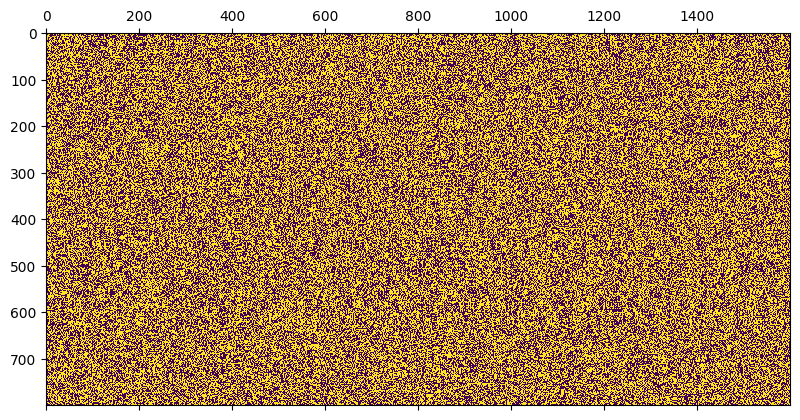

In [53]:
import matplotlib.pyplot as plt

plt.matshow(R_noisy)

R_train: [0.  0.5 1. ]


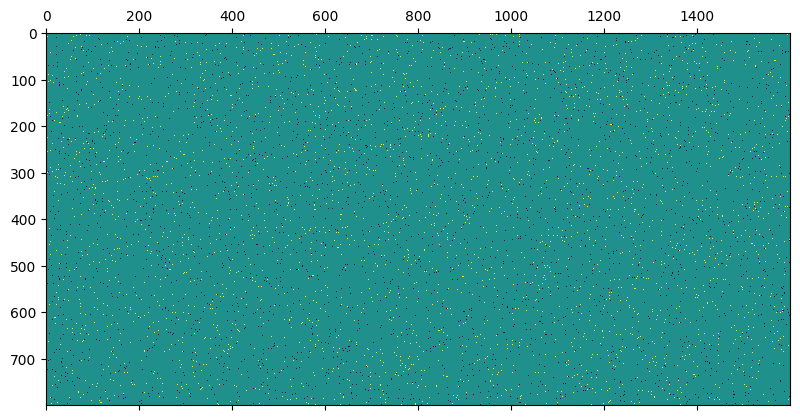

In [180]:
# option 1:
R_train = get_submatrix(R_noisy, ind_train_all)
R_train = R_train.toarray()
R_train[R_train == 0] = 0.5
R_train[R_train == -1] = 0
plt.matshow(R_train)
print(f"R_train: {np.unique(R_train)}")

R_train: [0. 1.]


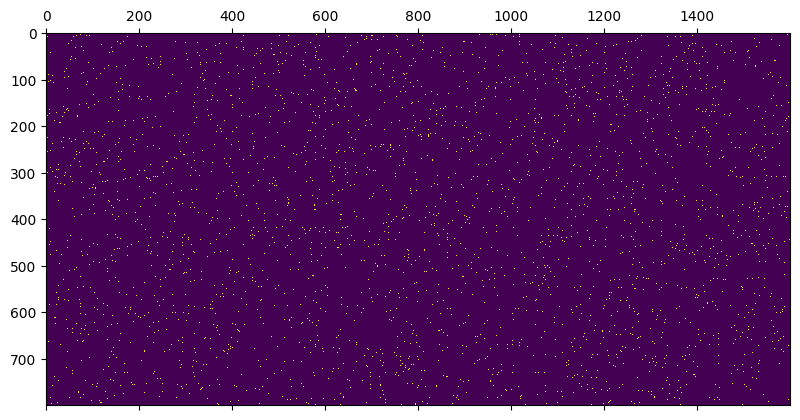

In [179]:
# option 2:
R_train = get_submatrix(R_noisy, ind_train_all)
R_train = R_train.toarray()
R_train[R_train == -1] = 0
plt.matshow(R_train)
print(f"R_train: {np.unique(R_train)}")

In [57]:
updateUV = r["updateUV"]

From document of rpy2: https://rpy2.github.io/doc/latest/html/introduction.html#calling-r-functions

In [132]:
# It can be very similar to R codes":
Y_miss = r.matrix(r.rnorm(25), nrow=5, ncol=5)
simD = r.matrix(r.rnorm(25), nrow=5, ncol=5)
simT = r.matrix(r.rnorm(25), nrow=5, ncol=5)

# simple numeric parameters
cc = 10
lamU = 0.1
lamV = 0.1
numLat = 10
iterpara = 1

In [ ]:
# Y_miss = robjects.conversion.py2rpy(R_train)

R_train.flatten()
R_train.shape
robjects.IntVector(R_train.flatten())
r.matrix(
    robjects.IntVector(R_train.flatten()),
    byrow=True,
    nrow=R_train.shape[0],
    ncol=R_train.shape[1],
)

0,0,0,...,0,0,0


In [90]:
Y_miss = r.matrix(
    robjects.IntVector(R_train.flatten()), nrow=R_train.shape[0], ncol=R_train.shape[1]
)

In [131]:
np.unique(R_train)

array([0., 1.])

[[1 1 1]
 [0 0 0]
 [0 0 0]]


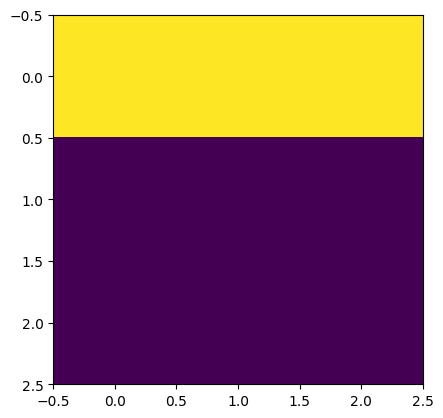

In [102]:
test = np.array([[1, 1, 1], [0, 0, 0], [0, 0, 0]])
print(test)
plt.imshow(test)

In [104]:
Y_miss = r.matrix(
    robjects.IntVector(test.flatten()),
    byrow=True,
    nrow=test.shape[0],
    ncol=test.shape[1],
)
print(Y_miss)

     [,1] [,2] [,3]
[1,]    1    1    1
[2,]    0    0    0
[3,]    0    0    0



In [186]:
print(R_train)

[[0.5 0.5 0.5 ... 0.5 0.5 0.5]
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]
 ...
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]
 [0.5 0.5 0.5 ... 0.5 0.5 0.5]
 [0.5 0.5 0.5 ... 0.5 0.  0.5]]


In [ ]:
# assume you've already sourced your R files and fetched updateUV
updateUV = r["updateUV"]

# sample data
Y_miss = R_train
Y_miss = r.matrix(
    robjects.IntVector(Y_miss.flatten()),
    byrow=True,
    nrow=Y_miss.shape[0],
    ncol=Y_miss.shape[1],
)
simD = np.eye(X.shape[0])
simD = r.matrix(
    robjects.IntVector(simD.flatten()),
    byrow=True,
    nrow=simD.shape[0],
    ncol=simD.shape[0],
)
simT = np.eye(Y.shape[0])
simT = r.matrix(
    robjects.IntVector(simT.flatten()),
    byrow=True,
    nrow=simT.shape[0],
    ncol=simT.shape[0],
)
# numeric / scalar params (plain python ints/floats are fine)
cc = 1
lamU, lamV = 0.1, 0.1
numLat = 200
iterpara = 1

# now call the R function (r_* are R matrices / data.frames)
out = updateUV(
    cc=cc,
    inMat=Y_miss,
    Sd=simD,
    St=simT,
    lamU=lamU,
    lamV=lamV,
    numLat=numLat,
    initMethod="useSeed",
    thisSeed=123,
    iterpara=iterpara,
    maxIter=100,
)

In [198]:
print(out)

$U
               [,1]      [,2]       [,3]          [,4]      [,5]        [,6]
  [1,] -0.832795279 0.7565383 0.74344240 -0.7570279697 0.6834442 -0.70257573
  [2,] -0.782514791 0.7045174 0.80739454 -0.7798292860 0.7682338 -0.71479065
  [3,] -0.551020882 0.7870654 0.72967653 -0.7570637129 0.6978500 -0.65090663
  [4,] -0.633802314 0.6760721 0.64866977 -0.6431658496 0.7333599 -0.72039657
  [5,] -0.632568695 0.6575092 0.53905999 -0.5895202480 0.4730267 -0.74868590
  [6,] -0.498264499 0.6114213 0.58953910 -0.6015025601 0.6330743 -0.46465088
  [7,] -0.529469590 0.5575636 0.78845453 -0.7269569131 0.5737805 -0.55817404
  [8,]  1.229856553 0.9258018 0.88229898 -0.8971528302 0.9261985 -0.75160102
  [9,] -0.626084425 0.6289344 0.75882356 -0.5863309414 0.6132879 -0.70370489
 [10,] -0.888933773 0.8182398 0.90474732 -0.8167972128 0.8868082 -0.71643675
 [11,] -0.583611798 0.4846894 0.79531892 -0.8399685535 0.7164309 -0.46428531
 [12,] -0.759424348 0.6814188 0.86655018 -0.8265497042 0.8062680 -0.66423

In [199]:
est_A, est_B = np.array(out[0]), np.array(out[1])

In [200]:
est_B.shape

(1600, 200)

In [201]:
# get the score
simD = np.eye(X.shape[0])
simT = np.eye(Y.shape[0])
prob_full = expit(simD @ est_A @ est_B.T @ simT.T)
# prob_full = X @ est_A @ est_B.T @ Y.T
prob_test = get_submatrix(prob_full, ind_test)
scores_test = mc_get_scores(R_test, prob_test)
print("Test score:", scores_test)

Test score: {'tn': 63902, 'fn': 63977, 'fp': 52, 'tp': 69, 'auc': 0.5028956701970796}


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

simD = cosine_similarity(X[:, :24])
simT = cosine_similarity(Y[:, :24])

In [216]:
np.unique(R_train)

array([0. , 0.5, 1. ])

In [221]:
# sample data
Y_miss = R_train
Y_miss = r.matrix(
    robjects.FloatVector(Y_miss.flatten()),
    byrow=True,
    nrow=Y_miss.shape[0],
    ncol=Y_miss.shape[1],
)
simD = cosine_similarity(X[:, :24])
simD = r.matrix(
    robjects.IntVector(simD.flatten()),
    byrow=True,
    nrow=simD.shape[0],
    ncol=simD.shape[0],
)
simT = cosine_similarity(Y[:, :24])
simT = r.matrix(
    robjects.IntVector(simT.flatten()),
    byrow=True,
    nrow=simT.shape[0],
    ncol=simT.shape[0],
)
# numeric / scalar params (plain python ints/floats are fine)
cc = 10
lamU, lamV = 0.1, 0.1
numLat = 25
iterpara = 1

# now call the R function (r_* are R matrices / data.frames)
out = updateUV(
    cc=cc,
    inMat=Y_miss,
    Sd=simD,
    St=simT,
    lamU=lamU,
    lamV=lamV,
    numLat=numLat,
    initMethod="useSeed",
    thisSeed=123,
    iterpara=iterpara,
    maxIter=100,
)

In [ ]:
est_A, est_B = np.array(out[0]), np.array(out[1])
# get the score
simD = cosine_similarity(X[:, :24])
simT = cosine_similarity(Y[:, :24])
prob_full = expit(simD @ est_A @ est_B.T @ simT.T)
# prob_full = X @ est_A @ est_B.T @ Y.T
prob_test = get_submatrix(prob_full, ind_test)
scores_test = mc_get_scores(R_test, prob_test)
print("Test score:", scores_test)

Test score: {'tn': 32678, 'fn': 30450, 'fp': 31276, 'tp': 33596, 'auc': 0.5175854978542269}
